In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

In [21]:
compas_two = pd.read_csv("compas-scores-two-years.csv")
compas_two.head(5)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [22]:
compas_two.columns

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='object')

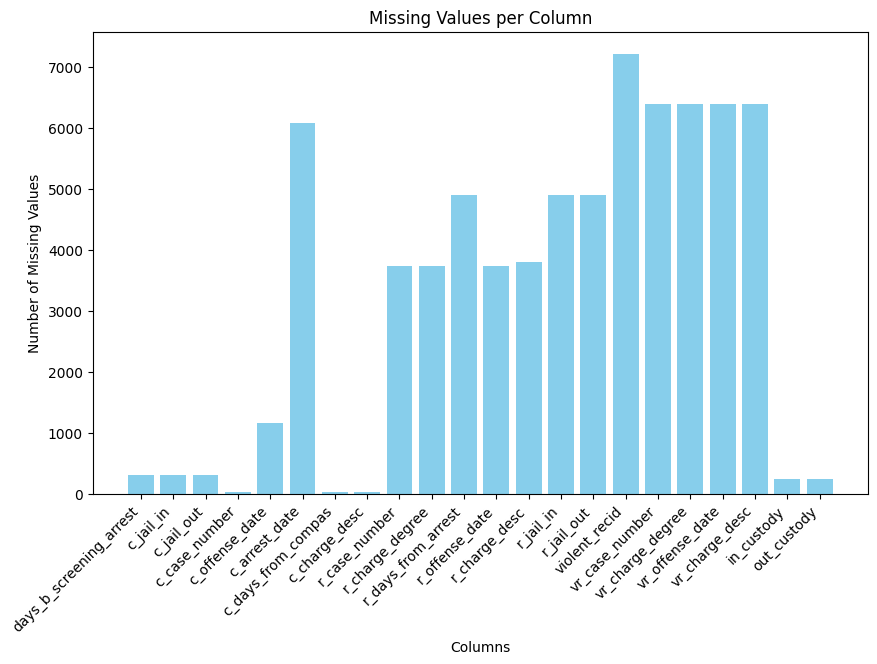

Columns with no missing values:
id
name
first
last
compas_screening_date
sex
dob
age
age_cat
race
juv_fel_count
decile_score
juv_misd_count
juv_other_count
priors_count
c_charge_degree
is_recid
is_violent_recid
type_of_assessment
decile_score.1
score_text
screening_date
v_type_of_assessment
v_decile_score
v_score_text
v_screening_date
priors_count.1
start
end
event
two_year_recid


In [23]:
missing_count = []
full_cols = []
missing_cols = []
for col in compas_two.columns:
    if compas_two[col].isna().sum() == 0:
        full_cols.append(col)
    else:
        missing_cols.append(col)
        missing_count.append(compas_two[col].isna().sum())

plt.figure(figsize=(10, 6))
plt.bar(missing_cols, missing_count, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Missing Values')
plt.xlabel("Columns")
plt.title('Missing Values per Column')
plt.show()
print("Columns with no missing values:")
for col in full_cols:
    print(col)

In [24]:
compas_two = compas_two.drop("violent_recid",axis=1)

In [25]:
numeric_cols = compas_two.select_dtypes(include=['float64', 'int64']).columns
for col in compas_two.columns:
    if col in numeric_cols:
        compas_two[col] = compas_two[col].fillna(compas_two[col].mean())
    else:
        compas_two[col] = compas_two[col].fillna(compas_two[col].mode()[0])
print("Missing values left:",compas_two.isna().sum().sum())

Missing values left: 0


In [26]:
compas_two['dob'] = pd.to_datetime(compas_two['dob'], dayfirst=True, errors='coerce')
compas_two['c_jail_in'] = pd.to_datetime(compas_two['c_jail_in'], dayfirst=True, errors='coerce')
compas_two['c_jail_out'] = pd.to_datetime(compas_two['c_jail_out'], dayfirst=True, errors='coerce')
compas_two['compas_screening_date'] = pd.to_datetime(compas_two['compas_screening_date'], dayfirst=True, errors='coerce')
compas_two['screening_date'] = pd.to_datetime(compas_two['screening_date'], dayfirst=True, errors='coerce')
compas_two['v_screening_date'] = pd.to_datetime(compas_two['v_screening_date'], dayfirst=True, errors='coerce')
compas_two['c_offense_date'] = pd.to_datetime(compas_two['c_offense_date'], dayfirst=True, errors='coerce')
compas_two['c_arrest_date'] = pd.to_datetime(compas_two['c_arrest_date'], dayfirst=True, errors='coerce')
compas_two['r_jail_in'] = pd.to_datetime(compas_two['r_jail_in'], dayfirst=True, errors='coerce')
compas_two['r_jail_out'] = pd.to_datetime(compas_two['r_jail_out'], dayfirst=True, errors='coerce')
compas_two['r_offense_date'] = pd.to_datetime(compas_two['r_offense_date'], dayfirst=True, errors='coerce')
compas_two['vr_offense_date'] = pd.to_datetime(compas_two['vr_offense_date'], dayfirst=True, errors='coerce')
compas_two['in_custody'] = pd.to_datetime(compas_two['in_custody'], dayfirst=True, errors='coerce')
compas_two['out_custody'] = pd.to_datetime(compas_two['out_custody'], dayfirst=True, errors='coerce')

In [27]:
X = compas_two.copy()
columns_to_drop = ['id', 'name', 'first', 'last', 'compas_screening_date','dob',
        'age_cat', 'decile_score','juv_misd_count', 'days_b_screening_arrest', 'c_jail_in', 
        'c_jail_out', 'c_case_number','c_offense_date', 'c_arrest_date', 
        'c_days_from_compas','c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'is_violent_recid',
       'vr_case_number', 'vr_charge_degree', 'vr_offense_date',
       'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text',
       'screening_date', 'v_type_of_assessment', 'v_decile_score',
       'v_score_text', 'v_screening_date', 'in_custody', 'out_custody',
       'priors_count.1', 'start', 'end', 'event', 'two_year_recid']
X = X.drop(columns=columns_to_drop)
charge_replace = {'F': 1, 'M': 0}
X['c_charge_degree'] = X['c_charge_degree'].replace(charge_replace)
X = pd.get_dummies(X, columns=['sex', 'race'], drop_first=True, dtype=float)
y = compas_two['two_year_recid']

In [29]:
X

,age,juv_fel_count,juv_other_count,priors_count,c_charge_degree,sex_Male,race_Asian,race_Caucasian,race_Hispanic,race_Native American,race_Other
0,69,0,0,0,1,1.0,0.0,0.0,0.0,0.0,1.0
1,34,0,0,0,1,1.0,0.0,0.0,0.0,0.0,0.0
2,24,0,1,4,1,1.0,0.0,0.0,0.0,0.0,0.0
3,23,0,0,1,1,1.0,0.0,0.0,0.0,0.0,0.0
4,43,0,0,2,1,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
7209,23,0,0,0,1,1.0,0.0,0.0,0.0,0.0,0.0
7210,23,0,0,0,1,1.0,0.0,0.0,0.0,0.0,0.0
7211,57,0,0,0,1,1.0,0.0,0.0,0.0,0.0,1.0
7212,33,0,0,3,0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [31]:
model_A = RandomForestClassifier(
    n_estimators=11,
    max_depth = 15,
    ccp_alpha=0.005,
    random_state=42,      
)
model_A.fit(X_train, y_train)

RandomForestClassifier(ccp_alpha=0.005, max_depth=15, n_estimators=11,
                       random_state=42)

Random Forest - Test Accuracy: 0.6625
Original confusion_matrix (TN, FP, FN, TP):
 [[602 188]
 [299 354]]


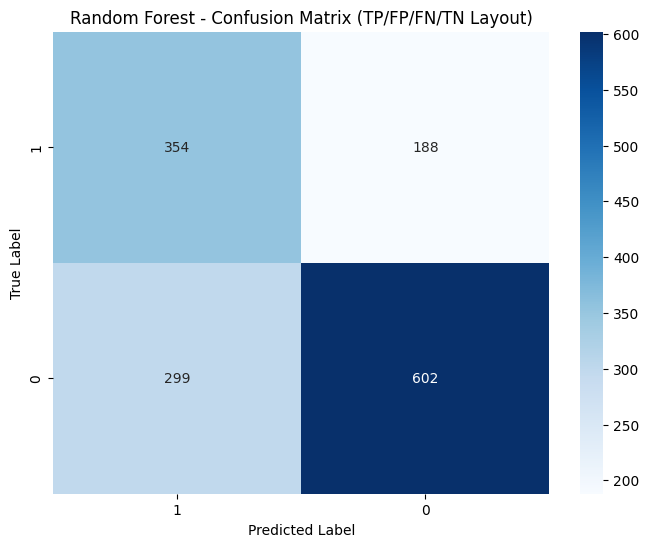

In [32]:
y_pred_A = model_A.predict(X_test)
accuracy_A = accuracy_score(y_test, y_pred_A)
print(f"Random Forest - Test Accuracy: {accuracy_A:.4f}")
cm_A = confusion_matrix(y_test, y_pred_A, labels=[0, 1])
print("Original confusion_matrix (TN, FP, FN, TP):\n", cm_A)
tn, fp, fn, tp = cm_A.ravel()
cm_display = np.array([[tp, fp],
                       [fn, tn]])
axis_labels_row = ['1', '0']
axis_labels_col = ['1', '0']
plt.figure(figsize=(8, 6)) # Set the figure size
sns.heatmap(cm_display, # Plot the REARRANGED matrix
            annot=True,        # Write the data value in each cell
            fmt="d",           # Format the annotations as integers
            cmap="Blues",      # Use the 'Blues' color map
            xticklabels=axis_labels_col, # Set labels for the x-axis reflecting the new order
            yticklabels=axis_labels_row)
plt.ylabel('True Label')     # Label for the y-axis
plt.xlabel('Predicted Label') # Label for the x-axis
plt.title('Random Forest - Confusion Matrix (TP/FP/FN/TN Layout)') # Plot title
plt.show()

Gradient Boost - Test Accuracy: 0.6812
Original confusion_matrix (TN, FP, FN, TP):
 [[614 176]
 [284 369]]


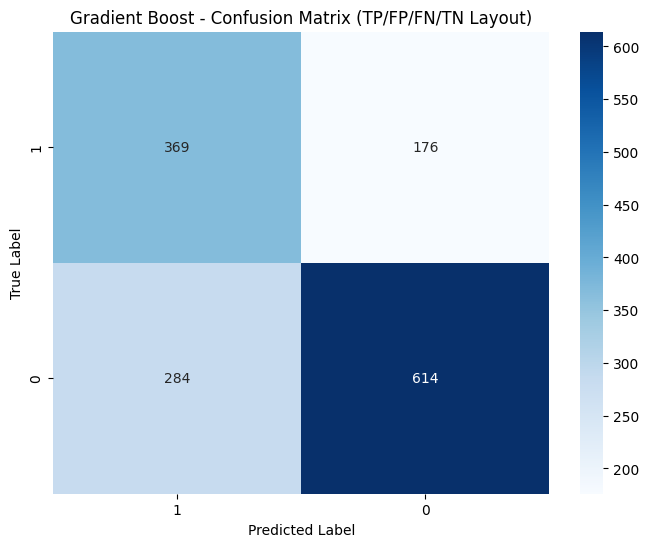

In [33]:
model_B = GradientBoostingClassifier(random_state=42)
model_B.fit(X_train, y_train)
y_pred_B = model_B.predict(X_test)
accuracy_B = accuracy_score(y_test, y_pred_B)
print(f"Gradient Boost - Test Accuracy: {accuracy_B:.4f}")
cm_B = confusion_matrix(y_test, y_pred_B, labels=[0, 1])
print("Original confusion_matrix (TN, FP, FN, TP):\n", cm_B)
tn, fp, fn, tp = cm_B.ravel()
cm_display = np.array([[tp, fp],
                       [fn, tn]])
axis_labels_row = ['1', '0']
axis_labels_col = ['1', '0']
plt.figure(figsize=(8, 6)) # Set the figure size
sns.heatmap(cm_display, # Plot the REARRANGED matrix
            annot=True,        # Write the data value in each cell
            fmt="d",           # Format the annotations as integers
            cmap="Blues",      # Use the 'Blues' color map
            xticklabels=axis_labels_col, # Set labels for the x-axis reflecting the new order
            yticklabels=axis_labels_row)
plt.ylabel('True Label')     # Label for the y-axis
plt.xlabel('Predicted Label') # Label for the x-axis
plt.title('Gradient Boost - Confusion Matrix (TP/FP/FN/TN Layout)') # Plot title
plt.show()

In [43]:
y_test

6020    0
5623    0
374     0
5796    0
5006    1
       ..
4206    0
1740    0
749     0
1476    0
5302    1
Name: two_year_recid, Length: 1443, dtype: int64

In [48]:
X2 = compas_two.copy()
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=101)

In [49]:
X2_test

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid,compas_bool
6020,9188,ernesto panduro-rojas,ernesto,panduro-rojas,2013-01-18,Male,1962-10-26,53,Greater than 45,Hispanic,...,Low,2013-01-18,NaT,2020-01-01,1,0,1169,0,0,0
5623,8575,ryan lennox,ryan,lennox,2014-03-06,Male,1982-03-13,34,25 - 45,African-American,...,Low,2014-03-06,2014-05-03,2014-03-07,1,1,757,0,0,0
374,561,jacob maynard,jacob,maynard,2014-02-04,Male,1982-01-17,34,25 - 45,Caucasian,...,Low,2014-02-04,2014-04-02,2014-02-04,1,0,787,0,0,0
5796,8831,josue espinosa,josue,espinosa,2013-02-17,Male,1964-04-20,51,Greater than 45,Hispanic,...,Low,2013-02-17,NaT,2013-02-17,0,0,1139,0,0,0
5006,7625,kymar forchin,kymar,forchin,2013-02-09,Male,1983-10-09,32,25 - 45,Other,...,Low,2013-02-09,NaT,2013-03-16,0,0,34,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4206,6422,lateria green,lateria,green,2013-10-15,Female,1993-12-02,22,Less than 25,African-American,...,High,2013-10-15,NaT,2013-10-17,2,2,899,0,0,1
1740,2643,benjamin chase,benjamin,chase,2013-03-01,Male,1983-06-25,32,25 - 45,Caucasian,...,Low,2013-03-01,2013-01-03,2013-03-01,0,0,1127,0,0,0
749,1140,edwin swinton,edwin,swinton,2013-05-17,Male,1944-05-30,71,Greater than 45,African-American,...,Low,2013-05-17,NaT,2013-06-10,8,24,1050,0,0,0
1476,2263,reuben billie,reuben,billie,2013-04-26,Male,1987-12-22,28,25 - 45,Native American,...,Low,2013-04-26,NaT,2013-06-13,2,48,1071,0,0,0


In [50]:
X2_test['compas_bool'] = (X2_test['decile_score'] >= 6).astype(int)
X2_test['RF'] = y_pred_A
X2_test ['GB'] = y_pred_B
X2_test

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid,compas_bool,RF,GB
6020,9188,ernesto panduro-rojas,ernesto,panduro-rojas,2013-01-18,Male,1962-10-26,53,Greater than 45,Hispanic,...,NaT,2020-01-01,1,0,1169,0,0,0,0,0
5623,8575,ryan lennox,ryan,lennox,2014-03-06,Male,1982-03-13,34,25 - 45,African-American,...,2014-05-03,2014-03-07,1,1,757,0,0,0,0,0
374,561,jacob maynard,jacob,maynard,2014-02-04,Male,1982-01-17,34,25 - 45,Caucasian,...,2014-04-02,2014-02-04,1,0,787,0,0,0,0,0
5796,8831,josue espinosa,josue,espinosa,2013-02-17,Male,1964-04-20,51,Greater than 45,Hispanic,...,NaT,2013-02-17,0,0,1139,0,0,0,0,0
5006,7625,kymar forchin,kymar,forchin,2013-02-09,Male,1983-10-09,32,25 - 45,Other,...,NaT,2013-03-16,0,0,34,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4206,6422,lateria green,lateria,green,2013-10-15,Female,1993-12-02,22,Less than 25,African-American,...,NaT,2013-10-17,2,2,899,0,0,1,0,1
1740,2643,benjamin chase,benjamin,chase,2013-03-01,Male,1983-06-25,32,25 - 45,Caucasian,...,2013-01-03,2013-03-01,0,0,1127,0,0,0,0,0
749,1140,edwin swinton,edwin,swinton,2013-05-17,Male,1944-05-30,71,Greater than 45,African-American,...,NaT,2013-06-10,8,24,1050,0,0,0,1,0
1476,2263,reuben billie,reuben,billie,2013-04-26,Male,1987-12-22,28,25 - 45,Native American,...,NaT,2013-06-13,2,48,1071,0,0,0,0,0


In [62]:
boolean_cols = ['two_year_recid','compas_bool', 'RF', 'GB']
grouped_counts = X2_test.groupby(['race'])[boolean_cols].sum()

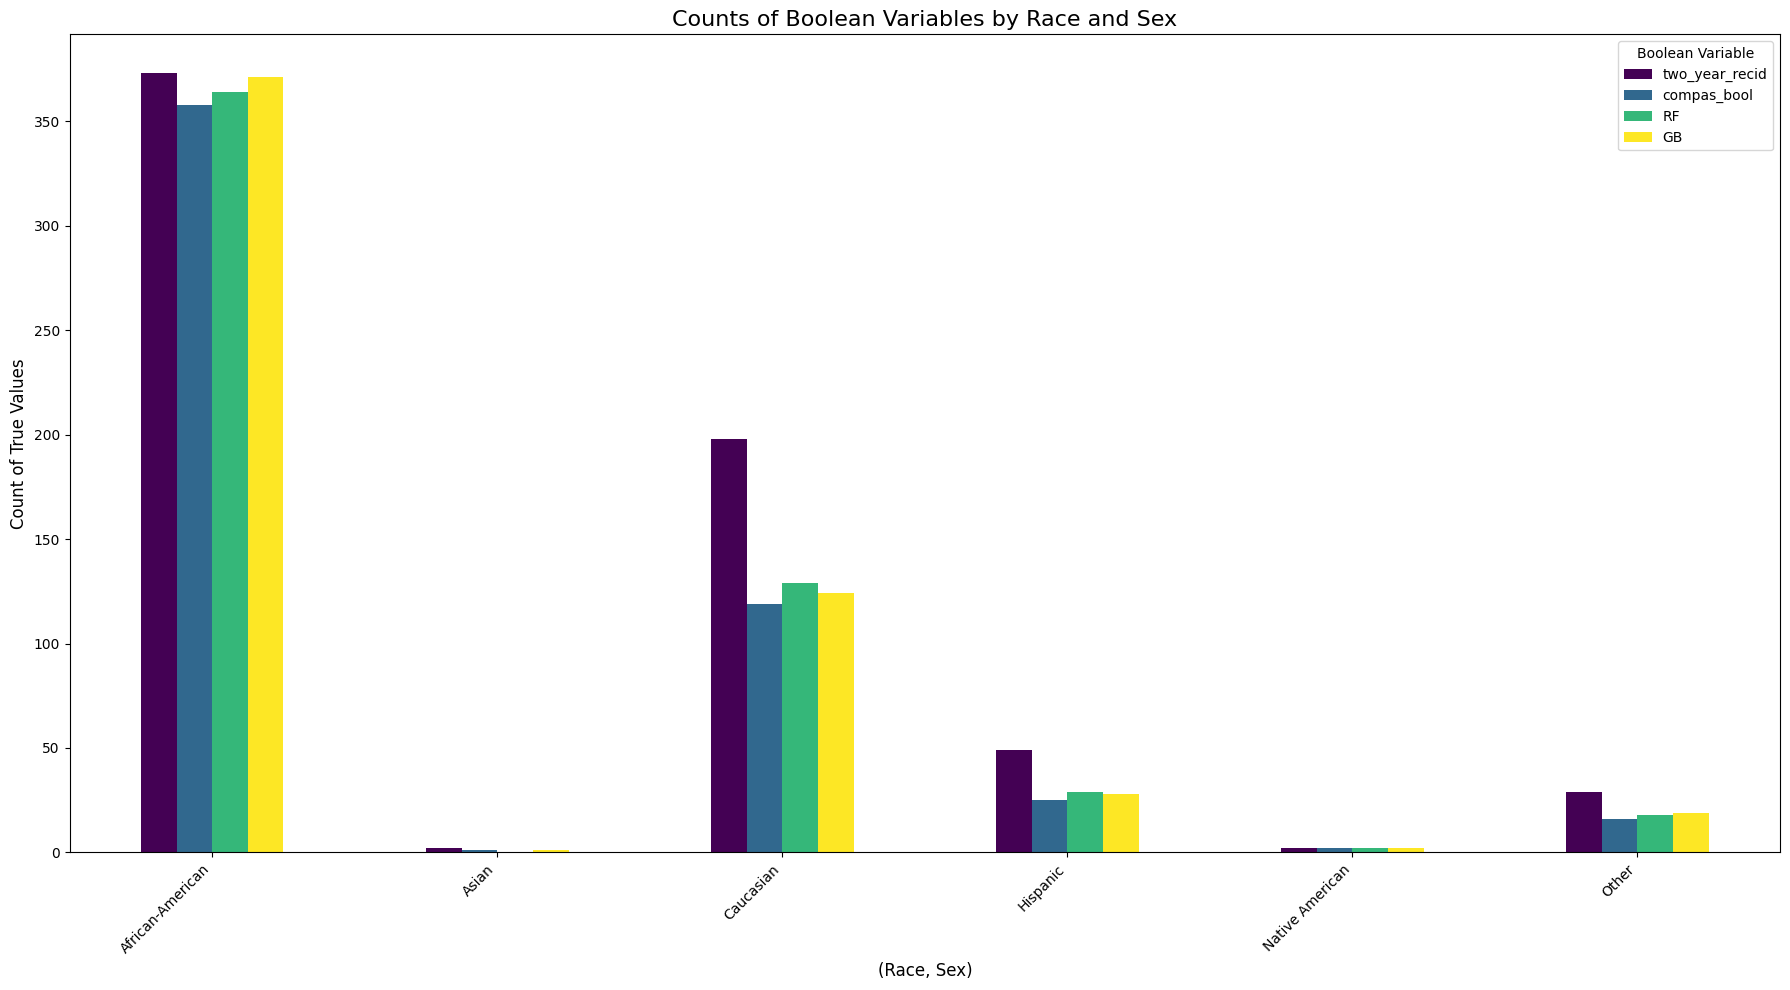

In [63]:
grouped_counts.plot(kind='bar', figsize=(18, 10), colormap='viridis') # You can choose other colormaps

plt.title('Counts of Boolean Variables by Race and Sex', fontsize=16)
plt.ylabel('Count of True Values', fontsize=12)
plt.xlabel('(Race, Sex)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.legend(title='Boolean Variable')
plt.tight_layout() # Adjust layout to fit everything nicely
plt.show()